# TARDIS — Model Training Notebook

All logic lives in `scripts/model/` — ce notebook ne fait qu'orchestrer.

| Module | Rôle |
|--------|------|
| `config.py` | Constantes (target, features, season map) |
| `preprocessing.py` | Pipeline de prétraitement + route stats |
| `sklearn_models.py` | sklearn / XGBoost / LightGBM |
| `dl_models.py` | PyTorch + TensorFlow MLPs |
| `evaluation.py` | Métriques + tableau comparatif |
| `predict.py` | `predict_delay(dep, arr, date, model, stats)` |
| `train.py` | `run_training()` — orchestrateur complet |

In [1]:
import sys, os

# Le notebook est à la racine du projet — scripts/ est donc accessible directement
if "." not in sys.path:
    sys.path.insert(0, ".")

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Working dir : {os.getcwd()}")

Working dir : /home/czp/Bureau/Tardis


## 1. Entraînement complet

Relance **Kernel → Restart & Run All** pour tout réentraîner et sauvegarder tous les modèles dans `models/`.

In [2]:
from scripts.model.train import run_training

best_pipeline, all_results, results_df = run_training(
    dataset_path="cleaned_dataset.csv",
    model_out="model.joblib",
    route_stats_out="route_stats.csv",
)

I0000 00:00:1779713594.777585    5856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779713594.838587    5856 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779713596.242100    5856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779713596.242425    5856 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


── Chargement des données ────────────────────────────────
   11,260 lignes | 133 routes uniques
   Train : 8,994 | Test : 2,249

── Prétraitement ─────────────────────────────────────────
   Dimensions après encodage : 125

── Baseline — RMSE : 4.789 | R² : -0.0002

── sklearn / XGBoost / LightGBM ──────────────────────────
  Linear Regression    | RMSE: 4.206 | MAE: 2.530 | R²: 0.2286
  Ridge                | RMSE: 4.202 | MAE: 2.530 | R²: 0.2299
  Random Forest        | RMSE: 3.847 | MAE: 2.080 | R²: 0.3546
  Gradient Boosting    | RMSE: 4.111 | MAE: 2.402 | R²: 0.2629
  XGBoost              | RMSE: 3.841 | MAE: 2.184 | R²: 0.3565
  LightGBM             | RMSE: 3.905 | MAE: 2.233 | R²: 0.3352

── Optimisation : XGBoost ────────────────────────────
Fitting 3 folds for each of 36 candidates, totalling 108 fits

  Best params : {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 400, 'model__subsample': 1.0}
  CV RMSE     : 4.923
  Test RMSE   : 3.955

── Classe

## 2. Tableau des résultats

In [3]:
from scripts.model.config import ALL_FEATURES, TARGET
from scripts.model.evaluation import baseline_metrics
from scripts.model.preprocessing import build_preprocessor, get_numpy_arrays
from sklearn.model_selection import train_test_split

df_tmp = pd.read_csv("cleaned_dataset.csv", parse_dates=["Date"])
df_tmp["day_of_week"] = df_tmp["Date"].dt.dayofweek

df_model = df_tmp.dropna(subset=[TARGET])
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
prep = build_preprocessor()
_, _, y_tr_np, y_te_np = get_numpy_arrays(prep, X_train, X_test, y_train, y_test)
baseline = baseline_metrics(y_tr_np, y_te_np)

print(f"Baseline RMSE : {baseline['RMSE']:.3f}")
print()
display(
    results_df
    .style
    .format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.4f}"})
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE", "MAE"])
    .background_gradient(cmap="RdYlGn",   subset=["R2"])
)

Baseline RMSE : 4.789



,RMSE,MAE,R2,vs Baseline
XGBoost,3.841,2.184,0.3565,19.8 %
Random Forest,3.847,2.080,0.3546,19.7 %
LightGBM,3.905,2.233,0.3352,18.5 %
XGBoost (tuned),3.955,2.172,0.3178,17.4 %
Gradient Boosting,4.111,2.402,0.2629,14.2 %
Ridge,4.202,2.530,0.2299,12.3 %
Linear Regression,4.206,2.530,0.2286,12.2 %


## 3. Comparaison visuelle

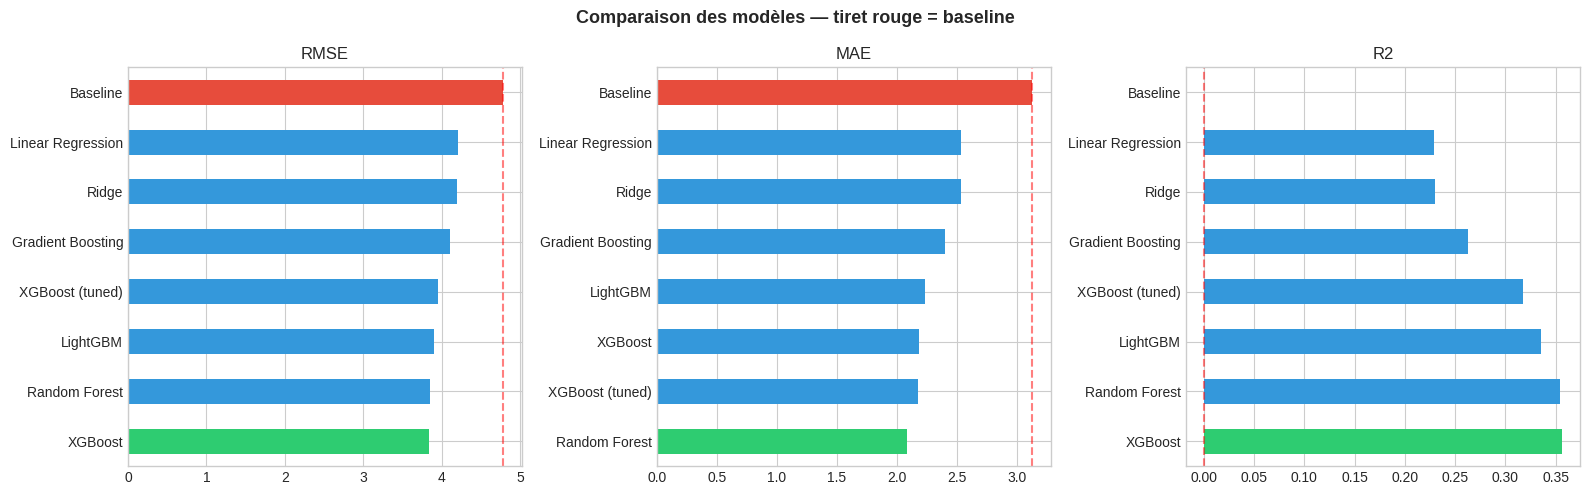

In [4]:
all_data = results_df[["RMSE", "MAE", "R2"]].copy()
all_data.loc["Baseline"] = [baseline["RMSE"], baseline["MAE"], baseline["R2"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, asc in zip(axes, ["RMSE", "MAE", "R2"], [True, True, False]):
    vals = all_data[metric].sort_values(ascending=asc)
    colors = [
        "#e74c3c" if i == "Baseline"
        else "#2ecc71" if i == vals.index[0]
        else "#3498db"
        for i in vals.index
    ]
    vals.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(metric)
    ax.axvline(all_data.loc["Baseline", metric], color="red", linestyle="--", alpha=0.5)
plt.suptitle("Comparaison des modèles — tiret rouge = baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Prédit vs Réel + Résidus

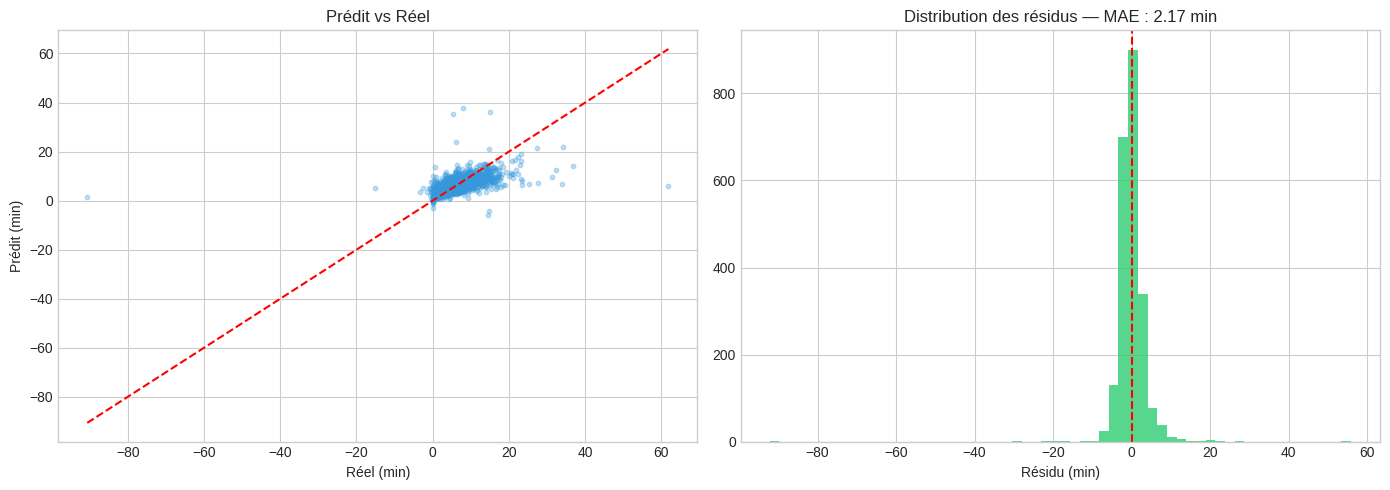

In [5]:
from sklearn.metrics import mean_absolute_error

prod_preds = best_pipeline.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, prod_preds, alpha=0.3, s=10, color="#3498db")
lims = [min(y_test.min(), prod_preds.min()), max(y_test.max(), prod_preds.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlabel("Réel (min)")
ax.set_ylabel("Prédit (min)")
ax.set_title("Prédit vs Réel")

residuals = y_test.to_numpy() - prod_preds
axes[1].hist(residuals, bins=60, color="#2ecc71", alpha=0.8, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Résidu (min)")
axes[1].set_title(f"Distribution des résidus — MAE : {mean_absolute_error(y_test, prod_preds):.2f} min")
plt.tight_layout()
plt.show()

## 5. Importance des variables

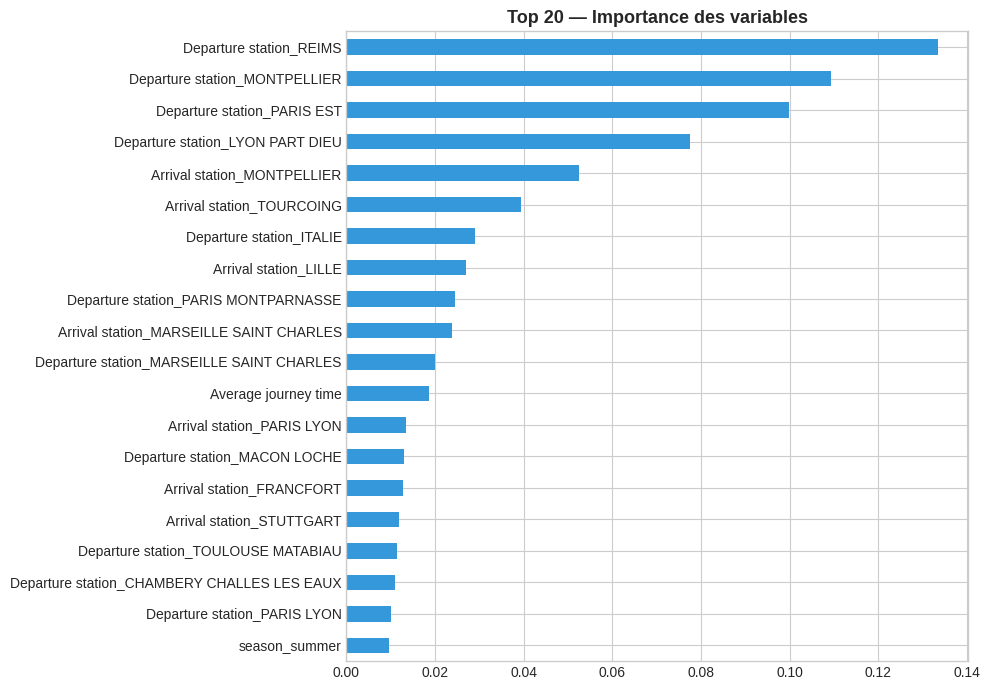

Top 10 :
  Departure station_REIMS                                 0.13355
  Departure station_MONTPELLIER                           0.10930
  Departure station_PARIS EST                             0.09987
  Departure station_LYON PART DIEU                        0.07763
  Arrival station_MONTPELLIER                             0.05252
  Arrival station_TOURCOING                               0.03944
  Departure station_ITALIE                                0.02894
  Arrival station_LILLE                                   0.02690
  Departure station_PARIS MONTPARNASSE                    0.02460
  Arrival station_MARSEILLE SAINT CHARLES                 0.02382


In [6]:
from scripts.model.config import NUMERIC_FEATURES, CATEGORICAL_FEATURES

final_estimator = best_pipeline.named_steps["model"]
prep_step       = best_pipeline.named_steps["prep"]
cat_enc         = prep_step.named_transformers_["cat"].named_steps["onehot"]
cat_names       = cat_enc.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
feat_names      = NUMERIC_FEATURES + cat_names

importances = pd.Series(
    getattr(final_estimator, "feature_importances_",
            getattr(final_estimator, "coef_", np.zeros(len(feat_names)))),
    index=feat_names,
).abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 20 — Importance des variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 :")
for feat, val in importances.head(10).items():
    print(f"  {feat:55s} {val:.5f}")

## 6. Vérification — prédire depuis deux villes

In [7]:
import joblib
from scripts.model.predict import predict_delay

model_artifact = joblib.load("model.joblib")
route_stats    = pd.read_csv("route_stats.csv")

# predict_delay attend le pipeline, pas le dict complet
loaded_pipeline = model_artifact["pipeline"] if isinstance(model_artifact, dict) else model_artifact

examples = [
    ("PARIS MONTPARNASSE", "BORDEAUX SAINT JEAN", pd.Timestamp("2024-12-15")),
    ("PARIS MONTPARNASSE", "NANTES",              pd.Timestamp("2025-01-10")),
    ("PARIS MONTPARNASSE", "MARSEILLE ST CHARLES",pd.Timestamp("2025-06-20")),
]

for dep, arr, date in examples:
    try:
        pred = predict_delay(dep, arr, date, loaded_pipeline, route_stats)
        print(f"{dep:30s} → {arr:30s} [{date.date()}]  → {pred:.1f} min")
    except ValueError as e:
        print(f"  ⚠ {e}")

PARIS MONTPARNASSE             → BORDEAUX SAINT JEAN            [2024-12-15]  → 3.8 min
PARIS MONTPARNASSE             → NANTES                         [2025-01-10]  → 5.5 min
PARIS MONTPARNASSE             → MARSEILLE ST CHARLES           [2025-06-20]  → 6.1 min


## 7. Modèles sauvegardés

```
models/
├── linear_regression.joblib
├── ridge.joblib
├── random_forest.joblib
├── gradient_boosting.joblib
├── xgboost.joblib
├── lightgbm.joblib
├── <best>_tuned.joblib
└── metadata.json       ← RMSE / MAE / R² de chaque modèle
model.joblib            ← meilleur modèle (copie du tuned)
route_stats.csv         ← stats médianes par route
```

Pour relancer depuis le terminal :
```bash
python -m scripts.model.train cleaned_dataset.csv
```